In [1]:
import pandas as pd
import numpy as np
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import transformers
from transformers import pipeline
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn import metrics
from itertools import chain
from nltk import NaiveBayesClassifier

In [2]:
data=pd.read_csv("book_reviews_sample.csv")

In [3]:
data.head()

,index,reviewText,rating
0,11494,Clean and funny. A bit busy with all the diffe...,3
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4
2,1463,Good thing that this is a free story. I read i...,1
3,10342,"Action, action, action! Equipment keeps gettin...",4
4,5256,this was hands down the worse book i have ever...,1


In [4]:
data["reviewText"][1]

'Alex a sexy hot cop and the PhD candidate. What a match that makes for a great fun and exciting book'

In [5]:
data['reviewtext_cleas']=data['reviewText'].str.lower()
data.head()

,index,reviewText,rating,reviewtext_cleas
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny. a bit busy with all the diffe...
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate. wha...
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story. i read i...
3,10342,"Action, action, action! Equipment keeps gettin...",4,"action, action, action! equipment keeps gettin..."
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...


In [6]:
data['reviewtext_cleas']=data.apply(lambda x: re.sub(r"([^\w\s])", "", x['reviewtext_cleas']), axis=1)

In [7]:
data.head()

,index,reviewText,rating,reviewtext_cleas
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...


In [8]:
vader_sentiment = SentimentIntensityAnalyzer()

In [15]:

data['vader_sentiment_score'] = data['reviewtext_cleas'].apply(lambda review: vader_sentiment.polarity_scores(review)['compound'])
# create labels
bins = [-1, -0.1, 0.1, 1]
names = ['negative', 'neutral', 'positive']

data['vader_sentiment_label'] = pd.cut(data['vader_sentiment_score'], bins, labels=names)
data.head(15)

,index,reviewText,rating,reviewtext_cleas,vader_sentiment_score,vader_sentiment_label,transformer_sentiment_label
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.7684,positive,[POSITIVE]
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.9325,positive,[POSITIVE]
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.6740,positive,[NEGATIVE]
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.6652,positive,[NEGATIVE]
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.4767,negative,[NEGATIVE]
5,7277,"Great book packed full with fast cars , crazy ...",4,great book packed full with fast cars crazy h...,0.7269,positive,[POSITIVE]
6,9781,I enjoyed the reader's digest very much. If I ...,4,i enjoyed the readers digest very much if i co...,0.5106,positive,[POSITIVE]
7,4583,This series has been good and I look forward t...,5,this series has been good and i look forward t...,0.7906,positive,[POSITIVE]
8,9797,I just could not get into this book.I all ways...,1,i just could not get into this booki all ways ...,0.0000,neutral,[NEGATIVE]
9,895,it was good to see where Dan and Elle was. And...,4,it was good to see where dan and elle was and ...,0.8107,positive,[POSITIVE]


<Axes: xlabel='vader_sentiment_label'>

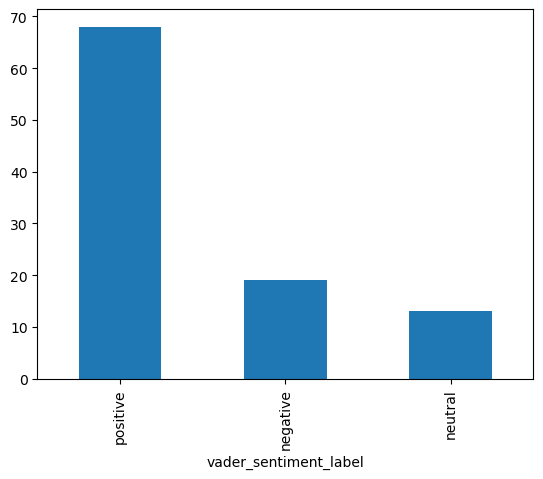

In [16]:
data['vader_sentiment_label'].value_counts().plot.bar()

In [11]:
transformer_pipeline=pipeline('sentiment-analysis')

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [12]:
transformer_labels = []

for review in data['reviewtext_cleas'].values:
    sentiment_list = transformer_pipeline(review)
    sentiment_label = [sent['label'] for sent in sentiment_list]
    transformer_labels.append(sentiment_label)
    
data['transformer_sentiment_label'] = transformer_labels

In [13]:
data.head()

,index,reviewText,rating,reviewtext_cleas,vader_sentiment_score,vader_sentiment_label,transformer_sentiment_label
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.7684,positive,[POSITIVE]
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.9325,positive,[POSITIVE]
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.6740,positive,[NEGATIVE]
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.6652,positive,[NEGATIVE]
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.4767,negative,[NEGATIVE]


<Axes: xlabel='transformer_sentiment_label'>

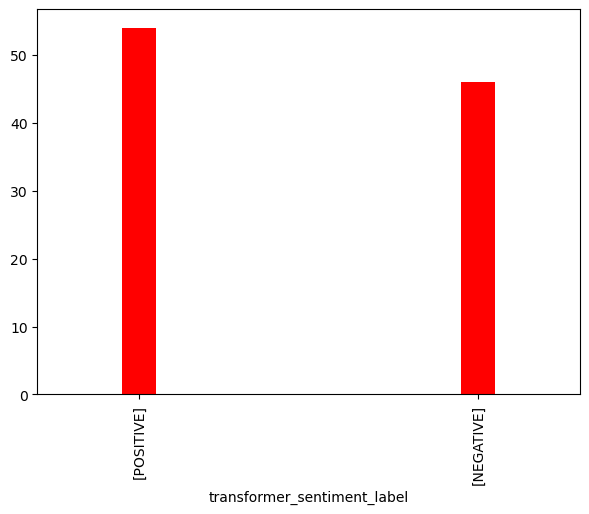

In [14]:
import matplotlib as plt
data['transformer_sentiment_label'].value_counts().plot.bar(color='red',width=.1,figsize=(7,5))